# 02. Synthetic Metro-style loan applications

**Purpose.** Generate realistic vehicle and equipment finance applications for an Australian non-bank lender that works through brokers, then check that the data behaves like real lending data without being so tidy that a model can simply reverse-engineer it.

The generator lives in `src/metro_deal_desk/generator.py` (reference values in `reference.py`) so the API and tests can reuse it. This notebook runs it and checks the result.

**All data here is synthetic.** Nothing is Metro Finance data. Where each number comes from:

| Part | Source |
|---|---|
| Relative risk by industry, business age, loan size | Measured from 273k US SBA loans (notebook 01) |
| Overall default level (about 5% over the loan's life) | Australian auto ABS arrears of 1.3 to 1.8% (S&P SPIN via Aquasia; Morningstar DBRS), scaled up from point-in-time arrears to lifetime default. Labelled assumption |
| Interest rates (about 7% to 14%) | Mozo 2026: secured business loans 6.8 to 9.5% at major banks; non-bank risk pricing above that. Assumption |
| Vehicle mix | FCAI VFACTS 2025: SUVs 60.7%, light commercials 22.6%, battery EVs 8.3% of new sales |
| Balloon, asset age, term effects | Asset-finance reasoning (labelled assumptions in code), replacing the SBA term effect that does not transfer |
| Form fields | Metro's public enquiry form: asset, state, amount, term, loan type, balloon |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import statsmodels.formula.api as smf
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score

from metro_deal_desk import generator as gen
from metro_deal_desk import reference as ref

pd.set_option("display.float_format", "{:,.3f}".format)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True})
BAR, HI = "#3b6ea5", "#c8553d"

## 1. Generate

20,000 historical applications with known outcomes (the loan book used to train the model) and 2,000 recent ones that form the live queue. The live queue arrives raw from brokers, so about 7% of it has deliberate data quality problems.

In [2]:
data = gen.build(n_history=20_000, n_incoming=2_000)
history, incoming_raw, truth = data["history"], data["incoming_raw"], data["truth"]
print(f"History: {len(history):,} applications, default rate {history['defaulted'].mean():.2%}")
print(f"Incoming queue: {len(incoming_raw):,} submissions, {len(truth)} with an injected problem")
history.sample(5, random_state=1).T

History: 20,000 applications, default rate 4.94%
Incoming queue: 2,004 submissions, 140 with an injected problem


,11456,16528,3253,18614,1544
application_id,APP-011457,APP-016529,APP-003254,APP-018615,APP-001545
submitted_date,2025-04-18 00:00:00,2025-12-24 00:00:00,2024-03-09 00:00:00,2026-04-09 00:00:00,2023-12-15 00:00:00
channel,Broker,Broker,Broker,Broker,Broker
broker_id,BRK-065,BRK-026,BRK-001,BRK-047,BRK-008
state,QLD,VIC,QLD,VIC,QLD
postcode,4453,3849,4351,3764,4652
entity_type,Trust,Sole trader,Sole trader,Company,Trust
abn,72776628570,32013628828,55728634276,92110133718,37153898501
abn_age_months,25,27,46,67,255
industry,Construction & trades,Transport & logistics,Health care,Wholesale trade,Agriculture


## 2. Does the portfolio look like vehicle and equipment finance?

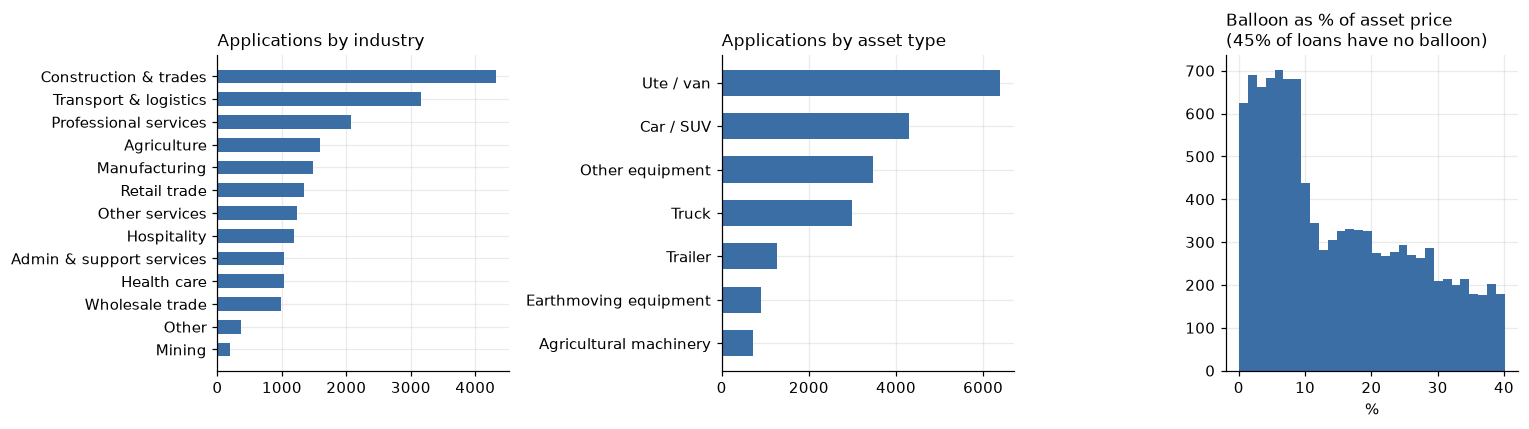

,mean,25%,50%,75%,max
asset_price,"66,195.825","29,200.000","50,300.000","73,500.000","349,600.000"
loan_amount,"64,364.305","28,300.000","48,800.000","72,125.000","362,900.000"
balloon_amount,"5,276.355",0.000,600.000,"6,900.000","103,400.000"
term_months,49.646,36.000,48.000,60.000,84.000
interest_rate,0.083,0.072,0.082,0.091,0.136
credit_score,729.378,636.000,729.000,823.000,"1,200.000"
abn_age_months,106.567,35.000,69.000,136.000,480.000


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in [(axes[0], "industry", "Applications by industry"),
                       (axes[1], "asset_category", "Applications by asset type")]:
    t = history[col].value_counts().sort_values()
    ax.barh(t.index, t.values, color=BAR, height=0.6); ax.set_title(title, loc="left", fontsize=11)
bp = (history["balloon_amount"] / history["asset_price"] * 100)
axes[2].hist(bp[bp > 0], bins=30, color=BAR)
axes[2].set_title(f"Balloon as % of asset price\n({(bp == 0).mean():.0%} of loans have no balloon)", loc="left", fontsize=11)
axes[2].set_xlabel("%")
plt.tight_layout(); plt.show()

history[["asset_price", "loan_amount", "balloon_amount", "term_months", "interest_rate",
         "credit_score", "abn_age_months"]].describe().T[["mean", "25%", "50%", "75%", "max"]]

## 3. Sanity check: do the SBA effects come through?

Fit the same kind of logistic regression used in notebook 01 on the synthetic history and compare odds ratios. They should point the same way and be of similar size, but not match exactly: the synthetic data adds credit scores, balloons, asset age and noise, and has far fewer loans.

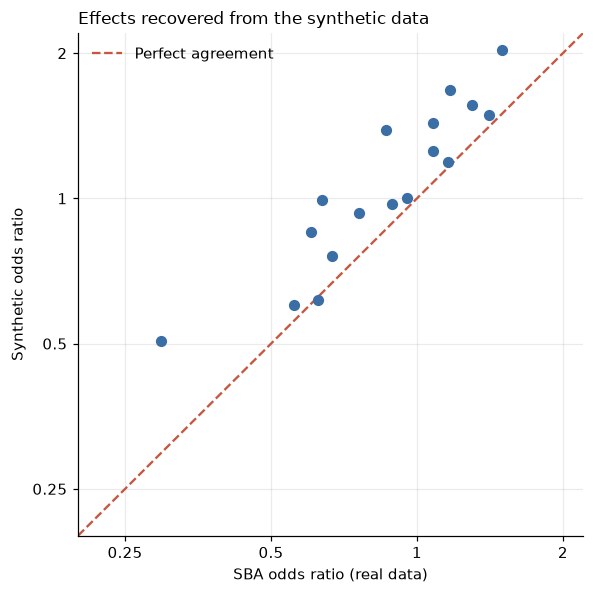

Correlation of log odds ratios: 0.91


,effect,sba_odds_ratio,synthetic_odds_ratio,same_direction
0,Industry: Admin & support services,0.950,1.000,False
1,Industry: Agriculture,0.600,0.850,True
2,Industry: Construction & trades,1.080,1.430,True
3,Industry: Health care,0.640,0.990,True
4,Industry: Hospitality,1.410,1.490,True
5,Industry: Manufacturing,0.890,0.970,True
6,Industry: Mining,0.300,0.510,True
7,Industry: Other,1.300,1.560,True
8,Industry: Other services,1.170,1.680,True
9,Industry: Retail trade,1.500,2.030,True


In [4]:
cal = json.loads(gen.CALIBRATION.read_text())
h = history.copy()
h["new_business"] = (h["abn_age_months"] <= 24).astype(int)
h["size_band"] = gen.size_band(h["loan_amount"].to_numpy())
fit = smf.logit("defaulted ~ C(industry, Treatment('Professional services')) + new_business"
                " + C(size_band, Treatment('<25k'))", data=h).fit(disp=0)
syn = np.exp(fit.params)

rows = []
for k, v in cal["industry"].items():
    if k == "Professional services": continue
    rows.append(("Industry: " + k, v["odds_ratio"], syn.get(f"C(industry, Treatment('Professional services'))[T.{k}]")))
rows.append(("New business (2 years or less)", cal["new_business_odds_ratio"], syn["new_business"]))
for k, v in cal["loan_size_odds_ratio_usd"].items():
    if k == "<25k": continue
    rows.append(("Loan size band: " + k, v, syn.get(f"C(size_band, Treatment('<25k'))[T.{k}]")))
compare = pd.DataFrame(rows, columns=["effect", "sba_odds_ratio", "synthetic_odds_ratio"]).dropna()
compare["same_direction"] = np.sign(np.log(compare["sba_odds_ratio"])) == np.sign(np.log(compare["synthetic_odds_ratio"]))

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(compare["sba_odds_ratio"], compare["synthetic_odds_ratio"], s=40, color=BAR, zorder=3)
lim = [0.2, 2.2]; ax.plot(lim, lim, color=HI, ls="--", lw=1.5, label="Perfect agreement")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lim); ax.set_ylim(lim)
ticks = [0.25, 0.5, 1, 2]
for axis in (ax.xaxis, ax.yaxis):
    axis.set_major_locator(plt.FixedLocator(ticks)); axis.set_major_formatter(plt.FixedFormatter([str(t) for t in ticks]))
    axis.set_minor_locator(plt.NullLocator())
ax.set_xlabel("SBA odds ratio (real data)"); ax.set_ylabel("Synthetic odds ratio")
ax.set_title("Effects recovered from the synthetic data", loc="left", fontsize=11); ax.legend(frameon=False)
plt.tight_layout(); plt.show()
print(f"Correlation of log odds ratios: {np.corrcoef(np.log(compare.iloc[:, 1]), np.log(compare.iloc[:, 2]))[0, 1]:.2f}")
compare.round(2)

**Reading the result.** The ranking carries across well (correlation of about 0.9 between real and synthetic log odds ratios), so riskier industries in the SBA data are riskier here too. Two expected differences:

- Most synthetic odds ratios sit a little above the line. The reference group (professional services) mostly finances cars, which carry little asset risk in the generator, so everyone else looks relatively riskier.
- The largest loans ($300k+) look riskier here than in the SBA data. These are mostly heavy trucks on long terms, often with balloons, which the asset-finance rules treat as higher risk. That is a deliberate design choice, not an error.

## 4. Circularity check: can a model just relearn the formula?

If the data were too clean, a model would score close to perfectly and the project would prove nothing. Two numbers to compare:

- **Ceiling:** how well the *true* hidden probability separates defaults from non-defaults. No model can beat this, because part of the outcome is pure chance.
- **Realistic model:** a plain logistic regression using only what a broker submits, with 5-fold cross-validation.

A healthy result is a model that lands somewhat below the ceiling, with AUC in the 0.7 to 0.8 range typical of real credit models.

In [5]:
# Recreate the same data in memory, this time keeping the hidden true probability.
full = gen.assign_outcomes(gen.generate_applications(22_000, seed=42)).iloc[:20_000]
ceiling = roc_auc_score(full["defaulted"], full["true_pd"])

X = history.copy()
X["balloon_pct"] = X["balloon_amount"] / X["asset_price"]
X["lvr"] = X["loan_amount"] / X["asset_price"]
X["log_loan"] = np.log(X["loan_amount"]); X["log_abn_age"] = np.log(X["abn_age_months"])
num = ["credit_score", "log_abn_age", "log_loan", "term_months", "balloon_pct", "asset_age_years", "lvr"]
cat = ["industry", "asset_category", "condition", "state", "entity_type", "channel"]
model = make_pipeline(ColumnTransformer([("num", StandardScaler(), num),
                                         ("cat", OneHotEncoder(handle_unknown="ignore"), cat)]),
                      LogisticRegression(max_iter=2000))
auc = cross_val_score(model, X[num + cat], X["defaulted"], cv=5, scoring="roc_auc")
print(f"Ceiling AUC (true hidden probability): {ceiling:.3f}")
print(f"Logistic regression AUC (5-fold CV):   {auc.mean():.3f} +/- {auc.std():.3f}")

Ceiling AUC (true hidden probability): 0.785
Logistic regression AUC (5-fold CV):   0.713 +/- 0.013


## 5. Injected data quality problems

The live queue contains the kinds of errors real broker submissions have. `incoming_dq_truth.csv` records exactly which rows were corrupted and how, so the validator in Block 2 can be tested against a known answer.

In [6]:
display(truth["injected_issue"].value_counts().rename("rows").to_frame())
examples = truth.drop_duplicates("injected_issue").merge(incoming_raw, on="application_id")
examples[["application_id", "injected_issue", "abn", "state", "postcode", "condition",
          "asset_description", "loan_amount", "balloon_amount", "term_months"]]

,rows
injected_issue,
asset_description_typo,22
loan_far_above_asset_value,21
invalid_term,18
postcode_state_mismatch,17
balloon_exceeds_loan,16
new_asset_too_old,15
abn_checksum_fail,14
missing_abn,13
duplicate_submission,4


,application_id,injected_issue,abn,state,postcode,condition,asset_description,loan_amount,balloon_amount,term_months
0,APP-020601,loan_far_above_asset_value,31907809257,WA,6781,New,2026 Tipper trailer,"91,600.000","4,500.000",36
1,APP-020034,postcode_state_mismatch,28006203870,NSW,3528,New,2026 Mazda CX-5,"39,400.000","10,400.000",60
2,APP-020132,abn_checksum_fail,89727526663,SA,5472,New,2026 Isuzu NPR 45-155,"183,500.000",0.000,84
3,APP-021609,asset_description_typo,49954397859,NSW,2345,Used,2020 For Ranger XLT,"31,500.000",0.000,60
4,APP-021538,missing_abn,None,TAS,7366,Used,2017 Kenworth T610,"68,000.000","8,100.000",60
5,APP-020830,new_asset_too_old,19378313537,VIC,3666,New,2016 Tandem box trailer,"35,300.000",600.000,60
6,APP-020392,invalid_term,71351247750,QLD,4296,New,2026 Rooftop solar PV system,"44,500.000",0.000,6
7,APP-020040,balloon_exceeds_loan,21094078087,VIC,3033,Used,2016 Isuzu NPR 45-155,"58,900.000","72,900.000",72
8,APP-021665-R,duplicate_submission,47572523658,SA,5714,Used,2025 Toyota HiLux SR5,"33,600.000",0.000,36


## 6. Outputs

| File | Rows | Use |
|---|---|---|
| `data/synthetic/applications_history.csv` | 20,000 | Train and test the credit model (has `defaulted`) |
| `data/synthetic/applications_incoming_raw.csv` | about 2,000 | Live queue for the API and dashboard; contains data problems; no outcome |
| `data/synthetic/incoming_dq_truth.csv` | about 140 | Answer key for testing the validator |

**Limitations** (for the README's data provenance section): the default process is a designed simulation, so model performance here says nothing about performance on real Metro data; credit score, balloon and asset-age effects are assumptions rather than measurements; SBA effects come from US government-guaranteed small business loans in the 2000s.